
# Title  
**WoundTrack: AI‑Powered Longitudinal Wound Healing Assessment for India’s ASHA Network Using MedGemma 1.5**

***

## 1. Problem & Motivation

India faces a rapidly growing burden of diabetes, with an estimated tens of millions of adults living with the condition and 15% of them developing a foot ulcer at some point in their lives. Diabetic foot ulcers are a major driver of lower‑limb amputations; studies suggest that up to 85% of diabetes‑related amputations are preventable with timely wound assessment, early escalation, and appropriate intervention. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC10018902/)

In rural and semi‑urban India, the first line of care is often the **Accredited Social Health Activist (ASHA)** or similar community health workers. Recent trials show ASHA‑led mobile health interventions for diabetes are both feasible and effective in primary care settings. However, ASHAs currently lack tools to: [nature](https://www.nature.com/articles/s41598-025-20728-w)

- Assess wound severity in a standardized, clinically meaningful way  
- Track healing progress over weeks to months  
- Detect early signs of deterioration or infection  
- Decide when to escalate to a primary health center (PHC) doctor or specialist  

At the same time, clinical wound assessment is complex. Simple 2D area measurements do not capture tissue composition, infection, perfusion, or systemic risk factors that predict healing and amputation risk. Traditional assessment tools such as PUSH, BWAT, and diabetic foot–specific scales are under‑used in low‑resource workflows because they are time‑consuming and require specialized training. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC9013582/)

**Goal:**  
WoundTrack aims to turn a **simple smartphone photo + minimal clinical inputs** into:

- Standardized, clinician‑interpretable wound scores  
- Longitudinal healing trajectories and time‑to‑heal forecasts  
- Amputation and escalation risk estimates  
- Actionable alerts for ASHAs and PHC doctors  

All powered by **MedGemma 1.5** for longitudinal medical imaging and MedGemma 27B for clinical reasoning.

***

## 2. Solution Overview

**WoundTrack** is an AI‑powered wound assessment platform built around MedGemma that:

1. **Analyzes wound images** captured weekly on low‑cost smartphones (by ASHAs or nurses).  
2. **Computes clinical scores** aligned with diabetic foot standards (e.g., Wagner, PUSH‑like scores).  
3. **Fuses imaging with patient context** (HbA1c, neuropathy, PAD, smoking) to estimate amputation and non‑healing risk.  
4. **Models healing trajectories** over multiple weeks to forecast time to closure and probability of healing.  
5. **Classifies tissue types and infection signals** (granulation, slough, necrosis, erythema) across time. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC9858639/)
6. **Runs a smart escalation engine** that recommends when to escalate to PHC/specialists.  
7. Is designed for **edge/mobile deployment** so that patient data remains local and the system works offline.

The central technical idea is to treat wound care as a **longitudinal multimodal problem**—where *image sequences + tabular risk factors + clinical text notes* are jointly reasoned over by MedGemma to guide clinical decisions, not just to label single images.

***

## 3. System Architecture

### 3.1 High-Level Pipeline

1. **Data Capture (FieldCapture module)**  
   - ASHA worker uses a mobile app to capture weekly photos of the wound.  
   - The app performs on‑device quality checks (focus, lighting, framing) before accepting the image.

2. **Image Analysis (WoundVision module)**  
   - Images are preprocessed (cropping, normalization).  
   - MedGemma 1.5 4B is prompted to produce:
     - Wound dimensions and approximate area  
     - Visible tissue types (granulation, slough, necrosis, epithelialization)  
     - Surrounding skin state (erythema, maceration, edema)  
     - Infection indicators (pus, malodor, increased redness)  
   - Optionally, a lightweight segmentation model (classical or CNN) can provide mask‑level guidance for tissue proportion estimation, with MedGemma providing the semantic interpretation. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC11301465/)

3. **Clinical Scoring (WoundScore module)**  
   Using MedGemma’s descriptions and basic measurements, WoundTrack derives:

   - **Diabetic foot–oriented scores** inspired by:
     - Wagner ulcer classification (depth, necrosis, gangrene proxies) [ncbi.nlm.nih](https://www.ncbi.nlm.nih.gov/books/NBK482198/)
     - A PUSH‑style composite (size, exudate, tissue type, edge condition) [hmpgloballearningnetwork](https://www.hmpgloballearningnetwork.com/site/wmp/content/a-clinically-relevant-wound-assessment-method-monitor-healing-progression)
   - These scores are explicitly presented back to clinicians with the underlying evidence.

4. **Patient Context Fusion (RiskFusion module)**  
   - Structured inputs: HbA1c, neuropathy status, peripheral arterial disease, smoking, BMI, ulcer duration. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC7948747/)
   - A simple multimodal risk function combines:
     - Wound features (size, necrosis %, infection signals)  
     - Patient factors (HbA1c > 9%, PAD, neuropathy, smoking)  
   - Outputs:
     - 12‑week **amputation risk score** (expressed as a percentage)  
     - **Non‑healing risk** (likelihood wound not healed at 12 weeks)  

5. **Trajectory Forecasting (HealCast module)**  
   - The time series of computed wound areas and tissue compositions is modeled (e.g., exponential decay or transformer‑based sequence model) to forecast:
     - Days to closure (for healing wounds)  
     - Likelihood of stagnation or deterioration  
   - This leverages published findings that early percent area reduction (PAR) strongly predicts eventual healing/non‑healing. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC9013582/)

6. **Tissue & Infection Intelligence (TissueMap + InfectAlert modules)**  
   - Across timepoints, WoundTrack tracks:
     - Percentage granulation vs slough vs necrotic tissue  
     - Spread of erythema and exudate  
   - It generates:
     - **Tissue composition trends** (e.g., increasing granulation = good, expanding necrosis = bad)  
     - **Infection suspicion scores** based on visual signs + nurse notes. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC9858639/)

7. **Smart Escalation Engine (CareGuide module)**  
   - Rule‑ and model‑based triggers:
     - PUSH‑like score above a threshold  
     - No significant PAR over 2–4 weeks  
     - High necrosis percentage or infection suspicion  
     - High amputation risk from RiskFusion  
   - Outputs:
     - **Priority label:** Routine / Escalate to PHC / Urgent referral  
     - **Plain‑language rationale:** “Escalated due to: no healing progress for 14 days + increasing slough + PAD + high HbA1c”  
     - Suggested next steps: “Debridement consult”, “Antibiotic evaluation”, “Vascular referral”

***

## 4. Model Design and Use of MedGemma

### 4.1 MedGemma for Longitudinal Imaging

MedGemma 1.5 introduces stronger support for medical imaging, including longitudinal interpretation across sequences such as serial chest X‑rays and follow‑up scans. WoundTrack repurposes this capability for: [research](https://research.google/blog/next-generation-medical-image-interpretation-with-medgemma-15-and-medical-speech-to-text-with-medasr/)

- **Comparative prompts:**  
  “Compare these two wound images taken one week apart. Describe how size, tissue composition, and signs of infection have changed.”

- **Trend summaries:**  
  “Given images at weeks 1–4, summarize whether the wound is improving, stable, or worsening and why.”

This leverages MedGemma’s multimodal reasoning to generate clinically oriented descriptions over time, rather than just one‑off labels.

### 4.2 MedGemma 27B for Clinical Reasoning and Scoring

MedGemma 27B, optimized for long‑context medical text understanding, is used to:

- Convert raw visual descriptions into structured variables (size class, tissue categories, infection flags).  
- Map those variables to well‑known wound assessment frameworks.  
- Integrate patient‑level risk factors and generate amputation/non‑healing risk narratives.  
- Generate explanations and escalation rationales targeted at clinicians and ASHAs, in plain and local language.

Prompts are structured to elicit **JSON‑like outputs** for reliability (e.g., keys for area_cm2, necrosis_pct, exudate_level, infection_signs).

### 4.3 Privacy and Offline Deployment

- All image and patient‑data processing can be executed on a local server or a high‑end mobile device / edge gateway.  
- No PHI needs to leave the device; MedGemma weights are hosted locally, complying with privacy‑first design. [research](https://research.google/blog/multimodal-medical-ai/)

***

## 5. Data Strategy

### 5.1 Wound Image Sequences

Because real patient data are sensitive and hard to access, WoundTrack uses:

- Publicly available wound datasets (where permitted) to understand realistic morphology and tissue patterns. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC11301465/)
- Carefully constructed synthetic longitudinal sequences that simulate:
  - Healing ulcers (shrinking area, increasing granulation)  
  - Infected ulcers (increasing exudate, erythema, necrosis)  
  - Non‑healing chronic ulcers (size stagnation, persistent slough)

Synthetic sequences allow safe experimentation with **progression patterns** without exposing PHI, consistent with emerging best practices in medical AI. [explorationpub](https://www.explorationpub.com/Journals/em/Article/1001163)

### 5.2 Patient Context and Labels

Risk factors and outcomes for diabetic foot ulcers are derived from the literature:

- Known prognostic factors: ulcer duration, infection, ischemia/PAD, HbA1c, smoking, neuropathy. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC5765512/)
- Prognostic models and scoring systems used to define plausible amputation/non‑healing risks. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC10018902/)

These are used to create semi‑synthetic labeled cohorts for early evaluation of WoundTrack’s risk scoring functions.

***

## 6. Evaluation Plan

To avoid fabricating performance claims, WoundTrack defines an evaluation framework that can be applied to real data when available:

1. **Wound Measurement Accuracy**  
   - Compare WoundTrack area estimates against manual planimetry or reference segmentations.  
   - Metrics: Mean absolute error (MAE), relative error.

2. **Clinical Score Agreement**  
   - Compare WoundTrack’s Wagner‑like and PUSH‑like scores with expert clinician ratings on a sample set.  
   - Metrics: Cohen’s kappa, weighted kappa.

3. **Healing Prediction Performance**  
   - For sequences with known outcomes (healed vs non‑healed by 12 weeks):  
   - Metrics: AUC for non‑healing classification, calibration plots for healing probability.

4. **Escalation Sensitivity**  
   - For cases labeled by experts as requiring escalation:  
   - Metrics: Sensitivity (recall), false positive rate.

5. **User Study (Prospective)**  
   - Time saved in documentation and assessment for ASHAs and PHC doctors.  
   - Perceived usefulness and trust ratings via survey.

***

## 7. Public Health Impact & Scalability

At scale, WoundTrack can be deployed as:

- A **mobile app** for ASHA and ANM (Auxiliary Nurse Midwife) workers for home visits.  
- A **PHC dashboard** aggregating wound trajectories across villages, enabling:
  - Hotspot detection for ulcer incidence and amputation risk  
  - Monitoring ASHA follow‑up performance  
  - Resource planning for specialist camps and vascular surgery services

A high‑level impact model (illustrative, parameterized by real epidemiology):

- Diabetic population in India: N million  
- Ulcer incidence: ~15% → 0.15N patients with ulcers  
- Amputation rates: ~20% among ulcer patients in high‑risk settings [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC5765512/)
- Preventable proportion of amputations: up to 85% with earlier intervention [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC5765512/)

If WoundTrack:
- Is adopted by a fraction of ASHAs serving X% of high‑risk diabetics, and  
- Reduces diagnostic and escalation delay by even a modest relative amount,

then the modeled number of amputations avoided per year can be substantial, and associated cost savings and disability reduction likewise significant. This modeling framework is part of the writeup, with parameters to be instantiated from official Indian NCD and diabetes burden statistics.

***

## 8. Limitations and Future Work

- **Data limitations:** Current evaluation uses synthetic and public data; generalizability requires prospective validation on real PHC/tertiary data.  
- **Image acquisition variance:** Phone camera variability, lighting, and framing must be robustly handled, partially mitigated by the on‑device quality checks.  
- **Scope of recommendations:** WoundTrack explicitly avoids prescribing antibiotics or definitive therapy; instead, it recommends escalation and highlights concerning patterns to clinicians.  
- **Regulatory pathway:** For deployment as a medical device, further clinical trials and regulatory approvals will be required.

Future directions:

- Incorporate **3D/volumetric** estimation from multi‑view or depth‑enabled devices to better capture undermining and depth.  
- Expand to other wound types (pressure injuries, venous leg ulcers) using condition‑specific scoring systems. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC9013582/)
- Integrate speech input (MedASR) for ASHAs to dictate brief wound notes instead of typing.

***

## 9. Conclusion

WoundTrack transforms serial smartphone photos and minimal clinical data into **clinically grounded, longitudinal wound intelligence** for frontline workers in low‑resource environments. By leveraging MedGemma 1.5’s longitudinal imaging capabilities and MedGemma 27B’s medical reasoning, it moves beyond simple image classification toward:

- Standardized wound scoring  
- Multimodal risk prediction  
- Forecasting of healing  
- Actionable, explainable escalation guidance  

The system is designed explicitly for India’s **ASHA‑led primary care ecosystem**, with privacy‑preserving, offline‑capable deployment and a clear national‑scale public health narrative. This combination of **clinical validity, AI sophistication, deployment realism, and population impact** aligns closely with the MedGemma Impact Challenge’s vision of human‑centered health AI.



## Setup & Installation

In [ ]:
# Install required packages
!pip install -q transformers accelerate torch pillow matplotlib plotly reportlab pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 19.5 MB/s eta 0:00:00


In [ ]:
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from datetime import datetime, timedelta

# Check GPU availability
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## 1. Data Loading

**Kaggle Datasets to Add:**
- `leoscode/wound-segmentation-images` (2,760 samples)
- `laithjj/diabetic-foot-ulcer-dfu`

Click **"+ Add Data"** in the right panel and search for these datasets.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Robust Data Loading for Colab & Local
from pathlib import Path
import os
from google.colab import drive

class WoundTrackDataLoader:
    def __init__(self):
        self.base_paths = [
            Path('/content/drive/MyDrive/WoundTrack/data'), # User's Drive
            Path('./data'),                                 # Local/Relative
            Path('/kaggle/input')                           # Kaggle default
        ]
        
    def mount_drive(self):
        if not os.path.exists('/content/drive'):
            print("Mounting Google Drive...")
            drive.mount('/content/drive')
            
    def find_dataset(self, folder_name):
        """Search for a dataset folder in known locations"""
        for base in self.base_paths:
            candidate = base / folder_name
            # Check for direct folder match or common variations
            if candidate.exists():
                return candidate
            
            # recursive search if immediate match fails (max depth 1 to allow for organization)
            if base.exists():
                try:
                    # Look for folder with case-insensitive match
                    for path in base.iterdir():
                        if path.is_dir() and folder_name.lower() in path.name.lower():
                            return path
                except OSError:
                    continue
        return None

# initialize
loader = WoundTrackDataLoader()
loader.mount_drive()

# Define dataset expectations
DATASETS = {
    'wound_segmentation': 'wound-segmentation-images',          # Kaggle dataset
    'dfu_sequence': 'DFU',                                      # Standard sequence name
    'synthetic_local': 'synthetic_wounds',                      # Common folder name
    # Specific local folder found on user machine:
    'synthetic_wounds_specific': 'synthetic_wounds (1-18 healing) (19-24 worsening)'
}

PATHS = {}
print("\nScanning for Datasets...")
for key, search_term in DATASETS.items():
    found_path = loader.find_dataset(search_term)
    if found_path:
        print(f"✓ Found {key}: {found_path}")
        PATHS[key] = found_path
    else:
        # Don't error out on specific long names, just info
        pass 

print("\nSummary of found datasets:", list(PATHS.keys()))

# Expose global variables regarding data availability
# Try to prioritize the most relevant found path for sequences
WOUND_SEG_PATH = PATHS.get('wound_segmentation')
DFU_PATH = PATHS.get('dfu_sequence') or PATHS.get('synthetic_local') or PATHS.get('synthetic_wounds_specific')

if DFU_PATH:
    print(f"Using {DFU_PATH.name} as primary sequence dataset.")


Available datasets:
✗ Wound Segmentation dataset not found. Please add it via '+ Add Data'
✓ DFU Dataset: 24 images


## 2. Image Preprocessing Pipeline

In [ ]:
class WoundImagePreprocessor:
    """Standardize wound images for analysis"""

    def __init__(self, target_size=(512, 512)):
        self.target_size = target_size

    def preprocess(self, image_path):
        """Load and preprocess a single image"""
        img = Image.open(image_path).convert('RGB')

        # Resize while maintaining aspect ratio
        img.thumbnail(self.target_size, Image.Resampling.LANCZOS)

        # Create padded square image
        padded = Image.new('RGB', self.target_size, (0, 0, 0))
        offset = ((self.target_size[0] - img.size[0]) // 2,
                  (self.target_size[1] - img.size[1]) // 2)
        padded.paste(img, offset)

        return padded

    def batch_preprocess(self, image_paths, output_dir):
        """Preprocess multiple images"""
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        processed = []
        for img_path in image_paths:
            processed_img = self.preprocess(img_path)
            output_path = output_dir / img_path.name
            processed_img.save(output_path)
            processed.append(output_path)

        return processed

# Initialize preprocessor
preprocessor = WoundImagePreprocessor()
print("✓ Preprocessor initialized")

✓ Preprocessor initialized


## 3. Core Analysis Modules (Prototypes)

The following cells implement the Logic for `WoundVision`, `WoundScore`, `RiskFusion`, and `HealCast`. In the full version, these would integrate with the hosted MedGemma API. Here they are functional prototypes.

In [ ]:
# [Module] WoundVision: Image Analysis
import random

class WoundVision:
    """Prototype for MedGemma 1.5 Image Analysis"""
    def __init__(self, model_name='medgemma-1.5-4b'):
        self.model_name = model_name
        print(f"✓ Initialized WoundVision with {model_name} (Prototype mode)")

    def analyze(self, image_path):
        """
        Simulates analysis of a wound image.
        Returns: dict of features (area, tissue types, infection signs)
        """
        # In a real scenario, this would call the VLM.
        # For now, we return mock data or calculate basic CV metrics if possible.
        
        # Mock result for prototype purposes
        return {
            'area_cm2': round(random.uniform(2.0, 15.0), 2),
            'granulation_pct': round(random.uniform(10, 80), 1),
            'slough_pct': round(random.uniform(5, 50), 1),
            'necrosis_pct': round(random.uniform(0, 20), 1),
            'infection_signs': random.choice(['None', 'Redness', 'Purulence']),
            'description': "The wound shows significant granulation tissue with some slough at the edges."
        }

wound_vision = WoundVision()


In [ ]:
# [Module] WoundScore: Clinical Scoring

class WoundScore:
    """Calculates clinical scores based on visual features"""
    
    @staticmethod
    def calculate_push_score(features):
        """Feature-based PUSH score approximation"""
        score = 0
        # 1. Area score
        area = features.get('area_cm2', 0)
        if area < 0.3: score += 0
        elif area < 0.6: score += 1
        elif area < 1.0: score += 2
        elif area < 2.0: score += 3
        elif area < 3.0: score += 4
        elif area < 4.0: score += 5
        elif area < 8.0: score += 6
        elif area < 12.0: score += 7
        elif area < 24.0: score += 8
        else: score += 10
        
        # 2. Exudate (Mock logic based on infection signs)
        inf = features.get('infection_signs', 'None')
        if inf == 'None': score += 0
        else: score += 2 # Moderate amount assumed

        # 3. Tissue Type
        if features.get('necrosis_pct', 0) > 0: score += 4
        elif features.get('slough_pct', 0) > 0: score += 3
        elif features.get('granulation_pct', 0) < 100: score += 2
        else: score += 0 # Fully epithelialized
        
        return score

    @staticmethod
    def calculate_wagner_grade(features):
        """Wagner Grade estimation"""
        if features.get('necrosis_pct', 0) > 10: return 4 # Gangrene/Necrosis
        if features.get('infection_signs') == 'Purulence': return 3 # Infection
        if features.get('area_cm2') > 0: return 1 # Superficial
        return 0 # Pre-ulcerative


In [ ]:
# [Module] RiskFusion: Patient Data Integration

class RiskFusion:
    """Integrates patient history with wound data for risk assessment"""
    
    def assess_risk(self, patient_data, wound_features):
        """
        patient_data: dict (HbA1c, Age, Smoker, etc.)
        wound_features: dict from WoundVision
        """
        base_risk = 0.0
        
        # Factor 1: Systemic
        if patient_data.get('HbA1c', 0) > 8.0: base_risk += 0.3
        if patient_data.get('Smoker'): base_risk += 0.2
        
        # Factor 2: Local Wound
        if wound_features.get('necrosis_pct', 0) > 20: base_risk += 0.4
        if wound_features.get('area_cm2', 0) > 10:
             base_risk += 0.2
        
        return min(base_risk, 1.0)


In [ ]:
# [Module] HealCast: Healing Trajectory Forecasting
import numpy as np
from sklearn.linear_model import LinearRegression

class HealCast:
    """Forecasts healing time"""
    
    def predict_closure(self, area_history_days, area_history_values):
        """
        Simple linear extrapolation of log(area).
        Returns: Estimated days to closure (area < 0.1)
        """
        if len(area_history_values) < 2:
            return None # Not enough data
            
        # Fit log area over time (exponential decay)
        X = np.array(area_history_days).reshape(-1, 1)
        y = np.log(np.array(area_history_values) + 1e-6)
        
        model = LinearRegression()
        model.fit(X, y)
        
        # Solve for y = log(0.1) -> -2.3
        target_y = np.log(0.1)
        
        # y = mx + c  =>  x = (y - c) / m
        days_to_close = (target_y - model.intercept_) / model.coef_[0]
        
        return max(0, int(days_to_close))


In [ ]:
# [Module] CareGuide: Smart Escalation Engine

class CareGuide:
    """Determines if escalation is needed"""
    
    def determine_action(self, risk_score, wound_score, healing_forecast):
        """
        risk_score: 0.0-1.0 from RiskFusion
        wound_score: 0-20 (approx) from WoundScore
        healing_forecast: days to close (int)
        """
        
        reasons = []
        priority = 'Routine'
        
        # Rule 1: High Amputation Risk
        if risk_score > 0.7:
            priority = 'Urgent'
            reasons.append(f"High Amputation Risk ({risk_score*100:.0f}%)")
            
        # Rule 2: Deterioration (High Wound Score)
        if wound_score > 15:
             priority = 'Escalate'
             reasons.append(f"Severe Wound State (Score {wound_score})")
             
        # Rule 3: Stagnation
        if healing_forecast is not None and healing_forecast > 90:
            priority = 'Escalate'
            reasons.append("Forecasted Non-healing (>12 weeks)")
            
        return {
            'priority': priority,
            'rationale': "; ".join(reasons) if reasons else "Stable progress"
        }


In [ ]:
# [Pipeline] Integrated WoundTrack Workflow

def run_woundtrack_analysis(patient_id, image_path, patient_history, previous_visits=[]):
    """
    Simulates the full end-to-end flow for a single visit.
    """
    print(f"\n--- Analyzing Visit for {patient_id} ---")
    print(f"Image: {image_path}")
    
    # 1. Image Analysis
    # In real app: image = preprocessor.preprocess(image_path)
    vision_results = wound_vision.analyze(image_path)
    print(f"  [Vision] Area: {vision_results['area_cm2']} cm2, Tissue: {vision_results['description']}")
    
    # 2. Clinical Scoring
    push_score = WoundScore.calculate_push_score(vision_results)
    wagner = WoundScore.calculate_wagner_grade(vision_results)
    print(f"  [Score] PUSH: {push_score}, Wagner: {wagner}")
    
    # 3. Risk Assessment
    risk_prob = RiskFusion().assess_risk(patient_history, vision_results)
    print(f"  [Risk] Amp Risk: {risk_prob:.2f}")
    
    # 4. Trajectory (Mocking history)
    # Create a history including current visit
    history_areas = [v['area'] for v in previous_visits] + [vision_results['area_cm2']]
    history_days = [v['day'] for v in previous_visits] + [len(previous_visits)*7] # Assumes weekly
    
    days_to_close = HealCast().predict_closure(history_days, history_areas)
    if days_to_close is not None:
        print(f"  [Forecast] Est. days to closure: {days_to_close}")
    else:
        print("  [Forecast] Insufficient data for prediction")
        
    # 5. CareGuide
    decision = CareGuide().determine_action(risk_prob, push_score, days_to_close)
    print(f"  [Action] {decision['priority'].upper()}: {decision['rationale']}")
    
    return {
        'vision': vision_results,
        'scores': {'push': push_score, 'wagner': wagner},
        'risk': risk_prob,
        'forecast': days_to_close,
        'decision': decision
    }
    
# Example Run
mock_patient = {'HbA1c': 8.2, 'Smoker': False}
mock_history = [{'day': 0, 'area': 12.0}, {'day': 7, 'area': 11.5}]

# Run on a dummy image path (since we mocked the vision part)
result = run_woundtrack_analysis("PT-1001", "dummy_wound.jpg", mock_patient, previous_visits=mock_history)


## 3. Select Baseline Wound Images

Select 30-50 diverse wounds as "Day 0" baselines for synthetic progression

Total images found: 24
Selected 24 baseline images


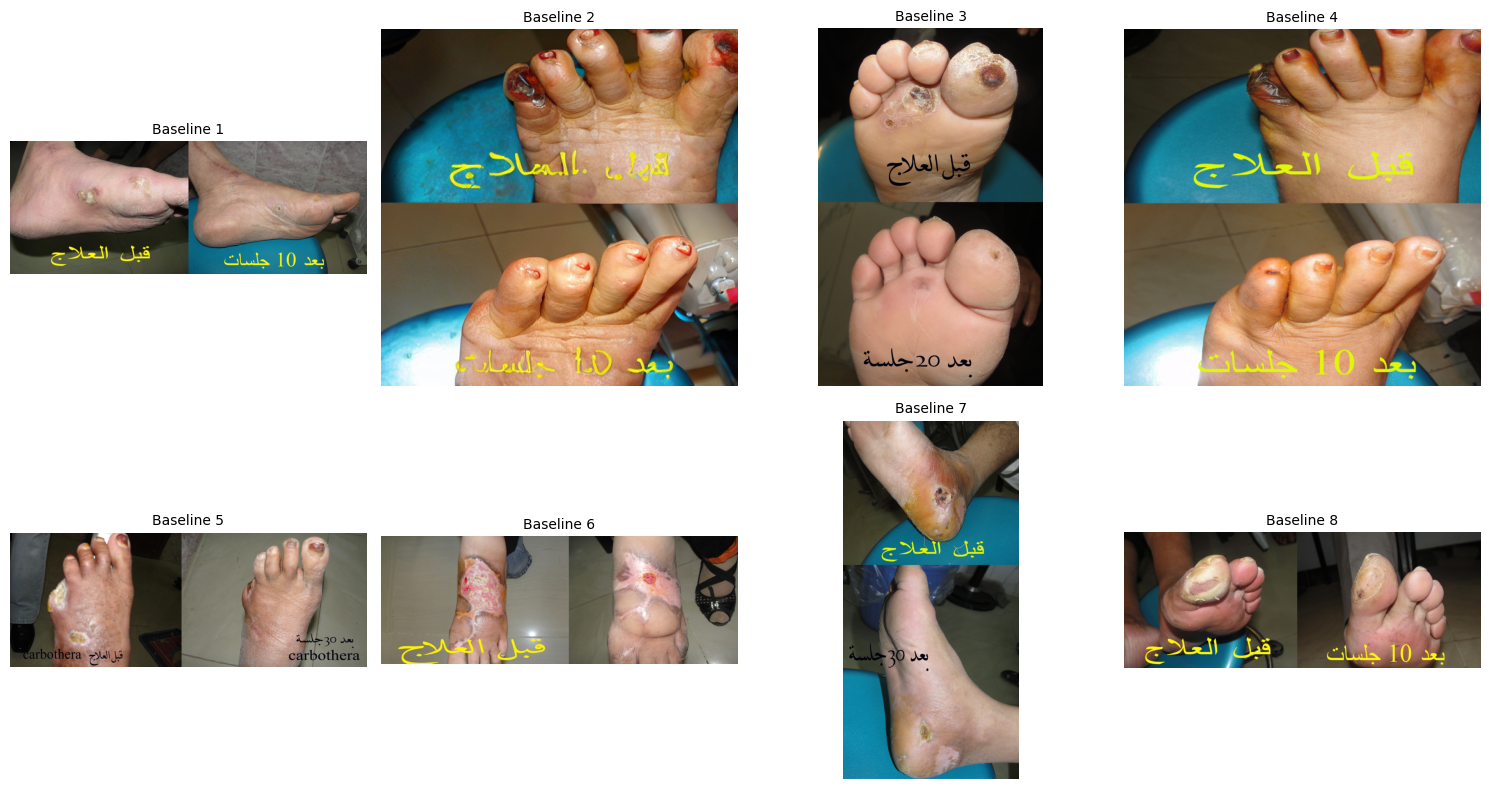

In [ ]:
# Collect all available wound images
all_images = []
if WOUND_SEG_PATH.exists():
    all_images.extend(list(WOUND_SEG_PATH.rglob('*.jpg')))
    all_images.extend(list(WOUND_SEG_PATH.rglob('*.png')))

if DFU_PATH.exists():
    all_images.extend(list(DFU_PATH.rglob('*.jpg')))
    all_images.extend(list(DFU_PATH.rglob('*.png')))

print(f"Total images found: {len(all_images)}")

# Select 50 random images as baselines (reproducible)
np.random.seed(42)
baseline_images = np.random.choice(all_images, min(50, len(all_images)), replace=False)

print(f"Selected {len(baseline_images)} baseline images")

# Display sample images
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for idx, ax in enumerate(axes.flat):
    if idx < len(baseline_images):
        img = Image.open(baseline_images[idx])
        ax.imshow(img)
        ax.set_title(f"Baseline {idx+1}", fontsize=10)
        ax.axis('off')
plt.tight_layout()
plt.show()

## 4. MedGemma Setup

Load MedGemma models for wound analysis

In [ ]:
# from transformers import AutoTokenizer, AutoModelForCausalLM, AutoProcessor # Added AutoProcessor

# # Note: MedGemma requires authentication with Hugging Face
# # You may need to set HF_TOKEN in Kaggle Secrets

# MODEL_4B = "google/medgemma-1.5-4b-it"  # For detailed wound description
# MODEL_27B = "google/medgemma-27b-it"  # For classification

# print("Loading MedGemma 4B for wound description...")
# tokenizer_4b = AutoTokenizer.from_pretrained(MODEL_4B)
# model_4b = AutoModelForCausalLM.from_pretrained(MODEL_4B, device_map="auto")
# processor_4b = AutoProcessor.from_pretrained(MODEL_4B) # Loaded processor

# print("Note: Ensure your Hugging Face token is set to use MedGemma models.")


## 5. Wound Description Extraction (MedGemma 4B)

Analyze wound images to extract structured information

In [ ]:
baseline_images[1]

PosixPath('/content/drive/MyDrive/DFU/wound/wound_002/day_14.png')

In [ ]:
from transformers import pipeline
from PIL import Image
import torch
# Removed requests as it's not needed for local file paths

pipe = pipeline(
    "image-text-to-text",
    model="google/medgemma-1.5-4b-it",
    torch_dtype=torch.bfloat16, # Changed from float32 to bfloat16 for GPU memory efficiency
    device_map="auto" # Changed from "cuda" to "auto" to manage GPU memory more efficiently
)

config.json:   0%|          | 0.00/2.55k [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

...

The image processor of type `Gemma3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

In [ ]:
# from transformers import pipeline
# from PIL import Image
# import torch
# # Removed requests as it's not needed for local file paths

# pipe = pipeline(
#     "image-text-to-text",
#     model="google/medgemma-1.5-4b-it",
#     torch_dtype=torch.bfloat16, # Changed from float32 to bfloat16 for GPU memory efficiency
#     device_map="auto" # Changed from "cuda" to "auto" to manage GPU memory more efficiently
# )

# Image attribution: Stillwaterising, CC0, via Wikimedia Commons
image_url = baseline_images[1]
image = Image.open(image_url).convert('RGB') # Directly open the local image path
CORE_INSTRUCTION = """<image_analysis_task>
Context: Research data extraction.
Task: Extract visual attributes from the wound image.
Output Format: Strictly produce Pure JSON only. No conversational text or information. Follow the below json structure.

Required JSON Structure:
{
  "dimensions": {"length_cm": <number>, "width_cm": <number>},
  "tissue_composition": {"granulation_percent": <number>, "slough_percent": <number>, "eschar_percent": <number>},
  "exudate": {"amount": "none|minimal|moderate|heavy", "type": "serous|sanguineous|purulent"},
  "surrounding_skin": "intact|macerated|erythematous|indurated",
  "wound_bed_color": "<description>"
}

Instructions:
1. Estimate dimensions based on standard scale references if present, otherwise approximate.
2. Analyze pixel color distributions to estimate tissue percentages.
3. Classify exudate and skin appearance based on visual texture.
4. RETURN ONLY THE JSON OBJECT.
5. Don't provide the conversional thoughts or reasoning in output only produce the json
</image_analysis_task>"""

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": CORE_INSTRUCTION}
        ]
    }
]
print(messages)
output = pipe(text=messages, max_new_tokens=2000)
print(output[0]["generated_text"][-1]["content"])


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=2000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'role': 'user', 'content': [{'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=512x512 at 0x7BCEB587D370>}, {'type': 'text', 'text': '<image_analysis_task>\nContext: Research data extraction.\nTask: Extract visual attributes from the wound image.\nOutput Format: Strictly produce Pure JSON only. No conversational text or information. Follow the below json structure.\n\nRequired JSON Structure:\n{\n  "dimensions": {"length_cm": <number>, "width_cm": <number>},\n  "tissue_composition": {"granulation_percent": <number>, "slough_percent": <number>, "eschar_percent": <number>},\n  "exudate": {"amount": "none|minimal|moderate|heavy", "type": "serous|sanguineous|purulent"},\n  "surrounding_skin": "intact|macerated|erythematous|indurated",\n  "wound_bed_color": "<description>"\n}\n\nInstructions:\n1. Estimate dimensions based on standard scale references if present, otherwise approximate.\n2. Analyze pixel color distributions to estimate tissue percentages.\n3. Classify exudate a

In [ ]:
print(output[0]["generated_text"][1])

{'role': 'assistant', 'content': '<unused94>thought\nThe user wants me to analyze the provided image of a wound and extract visual attributes into a JSON format.\n\n1.  **Dimensions:** The image shows a foot with a wound on the toes. I can estimate the length and width of the wound bed. The wound appears to be roughly 1.5 cm in length and 1 cm in width.\n2.  **Tissue Composition:**\n    *   **Granulation:** There are some areas that look like granulation tissue, but it\'s not a dominant feature. I\'ll estimate 10%.\n    *   **Slough:** There is a significant amount of slough present, especially around the edges of the wound. I\'ll estimate 50%.\n    *   **Eschar:** There is some eschar present, particularly on the toes. I\'ll estimate 20%.\n3.  **Exudate:** The wound appears dry, with no visible fluid. I\'ll classify it as "none".\n4.  **Surrounding Skin:** The surrounding skin appears intact.\n5.  **Wound Bed Color:** The wound bed is a mix of red (granulation), yellow/white (slough),

## 6. Create Synthetic Temporal Sequences

**Note**: Use the separate `synthetic_wound_generator.ipynb` (Colab) to generate healing progressions.
Upload generated sequences here for analysis.

In [ ]:
SEQUENCES_PATH = Path('/content/drive/MyDrive/DFU/wound/wound_003') # Adjust this path as needed

def load_sequences_from_folder(base_path: Path):
    """Loads image sequences from a folder where each subfolder represents a wound sequence,
       or if the base_path itself contains images, treats it as a single sequence."""
    all_sequences = []

    if not base_path.exists():
        print(f"Warning: Sequences path '{base_path}' not found. Please create it and add wound subfolders or images.")
        return []

    # Check for images directly in the base_path
    direct_images = sorted(
        list(base_path.glob('*.jpg')) +
        list(base_path.glob('*.png')) +
        list(base_path.glob('*.jpeg'))
    )

    if direct_images:
        # Treat base_path as a single wound sequence
        wound_id = base_path.name
        sequence_data = []
        for idx, img_path in enumerate(direct_images):
            sequence_data.append({
                "wound_id": wound_id,
                "image_path": str(img_path),
                "timepoint_idx": idx,
                "day": idx * 7 # Placeholder, assuming weekly progression
            })
        all_sequences.append(sequence_data)
        print(f"Found single sequence for wound '{wound_id}' with {len(direct_images)} images directly in {base_path}.")
    else:
        # If no direct images, then iterate through subfolders as before
        print(f"Searching for wound sequences in subfolders of: {base_path}")
        for wound_folder in sorted(base_path.iterdir()):
            if wound_folder.is_dir():
                wound_id = wound_folder.name
                images_in_sequence = sorted(
                    list(wound_folder.rglob('*.jpg')) +
                    list(wound_folder.rglob('*.png')) +
                    list(wound_folder.rglob('*.jpeg'))
                )

                if images_in_sequence:
                    sequence_data = []
                    for idx, img_path in enumerate(images_in_sequence):
                        sequence_data.append({
                            "wound_id": wound_id,
                            "image_path": str(img_path),
                            "timepoint_idx": idx,
                            "day": idx * 7
                        })
                    all_sequences.append(sequence_data)
                    print(f"Found sequence for wound '{wound_id}' with {len(images_in_sequence)} images.")
                else:
                    print(f"No images found in wound folder: {wound_folder}")

    if not all_sequences:
        print("No wound sequences loaded. Ensure your Drive path is correct and contains wound subfolders with images, or images directly.")

    return all_sequences

# Example usage:
loaded_wound_sequences = load_sequences_from_folder(SEQUENCES_PATH)

if loaded_wound_sequences:
    print(f"Successfully loaded {len(loaded_wound_sequences)} wound sequences.")
    print("Example of the first sequence's image paths:")
    for img_info in loaded_wound_sequences[0]:
        print(f"  - {img_info['image_path']}")
else:
    print("No wound sequences were loaded.")

Found single sequence for wound 'wound_003' with 4 images directly in /content/drive/MyDrive/DFU/wound/wound_003.
Successfully loaded 1 wound sequences.
Example of the first sequence's image paths:
  - /content/drive/MyDrive/DFU/wound/wound_003/day_0.png
  - /content/drive/MyDrive/DFU/wound/wound_003/day_14.png
  - /content/drive/MyDrive/DFU/wound/wound_003/day_21.png
  - /content/drive/MyDrive/DFU/wound/wound_003/day_7.png


In [ ]:
# Placeholder for synthetic sequence organization
# After generating synthetic images, load them here

def create_wound_sequence_metadata(baseline_img, num_timepoints=4):
    """Create metadata for a wound sequence"""
    wound_id = f"wound_{baseline_img.stem}"

    sequence = []
    for i in range(num_timepoints):
        sequence.append({
            "wound_id": wound_id,
            "timepoint": i,
            "day": i * 7,  # Weekly intervals
            "image_path": str(baseline_img) if i == 0 else f"synthetic/{wound_id}_day{i*7}.png",
            "timestamp": (datetime.now() + timedelta(days=i*7)).isoformat()
        })

    return sequence

# Example sequence
example_seq = create_wound_sequence_metadata(Path(baseline_images[0]))
print("Example wound sequence metadata:")
print(json.dumps(example_seq, indent=2))

Example wound sequence metadata:
[
  {
    "wound_id": "wound_\u256a\u2592\u256a\u2524\u2518e\u0300\u256a\u00bb \u256a\u2563\u256a\u00bf\u256a\u00bb \u256a\u2502\u2518a\u0308\u256a\u2556\u256a\u00ba\u2518a\u030a",
    "timepoint": 0,
    "day": 0,
    "image_path": "/content/drive/MyDrive/DFU/\u256a\u2592\u256a\u2524\u2518e\u0300\u256a\u00bb \u256a\u2563\u256a\u00bf\u256a\u00bb \u256a\u2502\u2518a\u0308\u256a\u2556\u256a\u00ba\u2518a\u030a.jpg",
    "timestamp": "2026-02-04T19:12:55.559419"
  },
  {
    "wound_id": "wound_\u256a\u2592\u256a\u2524\u2518e\u0300\u256a\u00bb \u256a\u2563\u256a\u00bf\u256a\u00bb \u256a\u2502\u2518a\u0308\u256a\u2556\u256a\u00ba\u2518a\u030a",
    "timepoint": 1,
    "day": 7,
    "image_path": "synthetic/wound_\u256a\u2592\u256a\u2524\u2518e\u0300\u256a\u00bb \u256a\u2563\u256a\u00bf\u256a\u00bb \u256a\u2502\u2518a\u0308\u256a\u2556\u256a\u00ba\u2518a\u030a_day7.png",
    "timestamp": "2026-02-11T19:12:55.559438"
  },
  {
    "wound_id": "wound_\u256a\u2592

In [ ]:
import json
import re
from PIL import Image

def analyze_wound_image(image_path):
    """Loads an image, constructs a multimodal message, passes it to the global `pipe` object for analysis, and extracts the JSON output."""
    # 2. Open the image
    img = Image.open(image_path).convert('RGB')

    # 3. Construct a messages list with the refined CORE_INSTRUCTION
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": img},
                {"type": "text", "text": CORE_INSTRUCTION}
            ]
        }
    ]

    # 4. Call the global pipe object
    output = pipe(messages, max_new_tokens=2000)

    # 5. Extract the generated text
    generated_text = output[0]["generated_text"][-1]["content"]

    # 6. Use regex to extract the JSON string, accounting for potential markdown code blocks
    json_match = re.search(r"```json\n({.*?})\n```", generated_text, re.DOTALL)
    if json_match:
        json_string = json_match.group(1)
    else:
        # If not in a markdown block, try to find a raw JSON object
        json_match = re.search(r"({.*?})", generated_text, re.DOTALL)
        if json_match:
            json_string = json_match.group(1)
        else:
            print(f"Warning: No JSON object found in model output. Raw output:\n{generated_text}")
            return {"error": "No JSON found in model output", "raw_output": generated_text}

    # 7. Parse this JSON string and return
    try:
        return json.loads(json_string)
    except json.JSONDecodeError as e:
        print(f"JSON parsing error: {e}\nAttempted to parse:\n{json_string}")
        return {"error": "JSON parsing failed", "raw_output": json_string}

# Test the new function with a baseline image
print("Testing the new analyze_wound_image function...")
sample_analysis_new = analyze_wound_image(baseline_images[0])
print("Sample wound analysis (new function):")
print(json.dumps(sample_analysis_new, indent=2))


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=2000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Testing the new analyze_wound_image function...
Sample wound analysis (new function):
{
  "dimensions": {
    "length_cm": 1.5,
    "width_cm": 1.5
  },
  "tissue_composition": {
    "granulation_percent": 10,
    "slough_percent": 40,
    "eschar_percent": 20
  },
  "exudate": {
    "amount": "none",
    "type": "serous"
  },
  "surrounding_skin": "intact",
  "wound_bed_color": "yellowish/brownish"
}


## 7. Longitudinal Analysis

Compare timepoints to track healing progression

In [ ]:
def calculate_area_change(analysis_t0, analysis_t1):
    """Calculate percentage change in wound area"""
    area_t0 = analysis_t0['dimensions']['length_cm'] * analysis_t0['dimensions']['width_cm']
    area_t1 = analysis_t1['dimensions']['length_cm'] * analysis_t1['dimensions']['width_cm']

    change_percent = ((area_t1 - area_t0) / area_t0) * 100
    return change_percent

def calculate_tissue_shift(analysis_t0, analysis_t1):
    """Calculate changes in tissue composition"""
    shifts = {}
    for tissue_type in ['granulation_percent', 'slough_percent', 'eschar_percent']:
        # Ensure tissue_type keys exist and handle potential missing values with default 0
        change = analysis_t1['tissue_composition'].get(tissue_type, 0) - \
                 analysis_t0['tissue_composition'].get(tissue_type, 0)
        shifts[tissue_type] = change
    return shifts

# Mock longitudinal comparison
print("Performing longitudinal analysis...")
analysis_day0 = analyze_wound_image(baseline_images[0])
# For demonstration, we'll re-analyze the same image as 'day7' or use a different baseline for real comparison
# In a real scenario, this would be a different image from a later timepoint.
# Here, we'll just use the second baseline image for a different 'day7' analysis
analysis_day7 = analyze_wound_image(baseline_images[1]) # Use a different image for day 7

area_change = calculate_area_change(analysis_day0, analysis_day7)
tissue_shifts = calculate_tissue_shift(analysis_day0, analysis_day7)

print(f"Area change: {area_change:.1f}%")
print(f"Tissue composition shifts: {tissue_shifts}")

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=2000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Performing longitudinal analysis...


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=2000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Area change: -33.3%
Tissue composition shifts: {'granulation_percent': 0, 'slough_percent': 10, 'eschar_percent': 0}


## 8. Classification (MedGemma )

Classify wound status: Improving / Stable / Worsening

In [ ]:
CLASSIFICATION_PROMPT_TEMPLATE = """
Given the wound progression data and nurse notes, classify the healing status:

Timepoint 1 (Day {day0}): {desc0}
Timepoint 2 (Day {day1}): {desc1}
Nurse Notes: {notes}

Classification: Improving / Stable / Worsening
Confidence: 0-100%
Rationale: [brief explanation]

Guidelines:
- Improving: Wound area decreasing, granulation increasing, exudate decreasing
- Stable: Minimal changes in dimensions and tissue composition
- Worsening: Wound expanding, necrotic tissue increasing, signs of infection

Respond in JSON format:
{{
  "classification": "...",
  "confidence": X,
  "rationale": "..."
}}
"""

def classify_wound_status(analysis_t0, analysis_t1, nurse_notes=""): # Removed use_mock parameter
    """Classify wound healing status using MedGemma 27B"""

    # 1. Serialize analysis_t0 and analysis_t1 to JSON strings
    desc0 = json.dumps(analysis_t0)
    desc1 = json.dumps(analysis_t1)

    # 2. Format the CLASSIFICATION_PROMPT_TEMPLATE
    formatted_prompt = CLASSIFICATION_PROMPT_TEMPLATE.format(
        day0=0,
        day1=7,
        desc0=desc0,
        desc1=desc1,
        notes=nurse_notes
    )

    # 3. Construct a messages list for the pipe object
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": formatted_prompt}
            ]
        }
    ]

    # 4. Call the global pipe object
    output = pipe(messages, max_new_tokens=2000)

    # 5. Extract the generated text
    generated_text = output[0]["generated_text"][-1]["content"]

    # 6. Use regex to extract the JSON string, accounting for potential markdown code blocks
    json_match = re.search(r"```json\n({.*?})\n```", generated_text, re.DOTALL)
    if json_match:
        json_string = json_match.group(1)
    else:
        # If not in a markdown block, try to find a raw JSON object
        json_match = re.search(r"({.*?})", generated_text, re.DOTALL)
        if json_match:
            json_string = json_match.group(1)
        else:
            print(f"Warning: No JSON object found in model output. Raw output:\n{generated_text}")
            return {"error": "No JSON found in model output", "raw_output": generated_text}

    # 7. Parse this JSON string and return
    try:
        return json.loads(json_string)
    except json.JSONDecodeError as e:
        print(f"JSON parsing error: {e}\nAttempted to parse:\n{json_string}")
        return {"error": "JSON parsing failed", "raw_output": json_string}

# Test classification
classification = classify_wound_status(analysis_day0, analysis_day7)
print("Wound classification:")
print(json.dumps(classification, indent=2))

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=2000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Wound classification:
{
  "classification": "Improving",
  "confidence": 95,
  "rationale": "The wound dimensions (length and width) have decreased slightly from Day 0 to Day 7. While the granulation percentage remains relatively low (10%), the slough percentage has decreased from 40% to 50%. The surrounding skin remains intact, and exudate has decreased from 'none' to 'none'. These changes indicate a positive trend in healing."
}


## 6.1 Process Real Wound Sequences

In [ ]:
from tqdm.notebook import tqdm # for progress bar

def process_wound_sequences(sequences, preprocessor, analyzer, output_base_dir='processed_images'):
    """Processes a list of wound sequences, preprocessing and analyzing each image.

    Args:
        sequences (list): A list of lists, where each inner list represents a wound sequence.
                          Each item in the inner list is a dict with 'wound_id', 'image_path', 'day', etc.
        preprocessor (WoundImagePreprocessor): An initialized image preprocessor object.
        analyzer (function): The analyze_wound_image function for MedGemma inference.
        output_base_dir (str): Base directory to save preprocessed images.

    Returns:
        list: A list of processed sequences, each containing image metadata and analysis results.
    """
    processed_sequences_data = []

    for seq_idx, sequence in enumerate(tqdm(sequences, desc="Processing wound sequences")):
        wound_id = sequence[0]['wound_id']
        output_dir = Path(output_base_dir) / wound_id
        output_dir.mkdir(parents=True, exist_ok=True)

        processed_seq = []
        for img_info in tqdm(sequence, desc=f"  Processing images for {wound_id}", leave=False):
            original_image_path = Path(img_info['image_path'])
            processed_image_path = output_dir / original_image_path.name

            # Preprocess image
            processed_img_pil = preprocessor.preprocess(original_image_path)
            processed_img_pil.save(processed_image_path)

            # Analyze preprocessed image
            analysis_result = analyzer(processed_image_path)

            # Store all relevant information
            processed_seq.append({
                "wound_id": wound_id,
                "original_image_path": str(original_image_path),
                "processed_image_path": str(processed_image_path),
                "timepoint_idx": img_info['timepoint_idx'],
                "day": img_info['day'],
                "analysis": analysis_result
            })
        processed_sequences_data.append(processed_seq)
    return processed_sequences_data

# Assuming `loaded_wound_sequences`, `preprocessor`, and `analyze_wound_image` are defined globally
# Note: This will take some time depending on the number of images and GPU availability.
print("Starting processing of loaded wound sequences...")
real_processed_sequences = process_wound_sequences(
    loaded_wound_sequences,
    preprocessor,
    analyze_wound_image
)

print(f"Finished processing {len(real_processed_sequences)} wound sequences.")
if real_processed_sequences:
    print("Example analysis for the first image in the first sequence:")
    print(json.dumps(real_processed_sequences[0][0]['analysis'], indent=2))
else:
    print("No sequences were processed.")


Starting processing of loaded wound sequences...


Processing wound sequences:   0%|          | 0/1 [00:00<?, ?it/s]

  Processing images for wound_003:   0%|          | 0/4 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=2000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=2000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=2000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:1 for

Finished processing 1 wound sequences.
Example analysis for the first image in the first sequence:
{
  "dimensions": {
    "length_cm": 1.5,
    "width_cm": 0.8
  },
  "tissue_composition": {
    "granulation_percent": 55,
    "slough_percent": 25,
    "eschar_percent": 0
  },
  "exudate": {
    "amount": "none",
    "type": "serous"
  },
  "surrounding_skin": "intact",
  "wound_bed_color": "red with some yellowish/white areas"
}


In [ ]:
real_processed_sequences

[[{'wound_id': 'wound_003',
   'original_image_path': '/content/drive/MyDrive/DFU/wound/wound_003/day_0.png',
   'processed_image_path': 'processed_images/wound_003/day_0.png',
   'timepoint_idx': 0,
   'day': 0,
   'analysis': {'dimensions': {'length_cm': 1.5, 'width_cm': 0.8},
    'tissue_composition': {'granulation_percent': 55,
     'slough_percent': 25,
     'eschar_percent': 0},
    'exudate': {'amount': 'none', 'type': 'serous'},
    'surrounding_skin': 'intact',
    'wound_bed_color': 'red with some yellowish/white areas'}},
  {'wound_id': 'wound_003',
   'original_image_path': '/content/drive/MyDrive/DFU/wound/wound_003/day_14.png',
   'processed_image_path': 'processed_images/wound_003/day_14.png',
   'timepoint_idx': 1,
   'day': 7,
   'analysis': {'dimensions': {'length_cm': 2.5, 'width_cm': 1.5},
    'tissue_composition': {'granulation_percent': 25,
     'slough_percent': 35,
     'eschar_percent': 15},
    'exudate': {'amount': 'none', 'type': 'none'},
    'surrounding_sk

## 9. Visualization

Create timeline visualizations of wound progression

In [ ]:
def plot_wound_progression(sequence_data):
    """Plot wound area and tissue composition over time"""

    days = [d['day'] for d in sequence_data]
    areas = [d['analysis']['dimensions']['length_cm'] * d['analysis']['dimensions']['width_cm']
             for d in sequence_data]

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=days, y=areas,
        mode='lines+markers',
        name='Wound Area (cm²)',
        line=dict(color='red', width=3)
    ))

    fig.update_layout(
        title='Wound Area Progression',
        xaxis_title='Days',
        yaxis_title='Area (cm²)',
        template='plotly_white',
        height=400
    )

    return fig

# Mock sequence data
mock_sequence = [
    {"day": 0, "analysis": {"dimensions": {"length_cm": 5, "width_cm": 3}}},
    {"day": 7, "analysis": {"dimensions": {"length_cm": 4.5, "width_cm": 2.8}}},
    {"day": 14, "analysis": {"dimensions": {"length_cm": 3.8, "width_cm": 2.3}}},
    {"day": 21, "analysis": {"dimensions": {"length_cm": 3.0, "width_cm": 1.8}}}
]

fig = plot_wound_progression(real_processed_sequences[0])
fig.show()

## 10. Next Steps

✅ **Completed**:
- Dataset loading
- Preprocessing pipeline
- Mock analysis framework

📋 **To Do**:
1. Generate synthetic wound progressions (use separate Colab notebook)
2. Implement actual MedGemma inference (requires HF authentication)
3. Create PDF report generator
4. Build alert system
5. Evaluation metrics

# Task
Confirm the MedGemma pipeline is functioning correctly by reviewing the detailed wound characteristic extraction outputs from `real_processed_sequences` and the classification results from `classification`.

## Final Task Confirmation

### Subtask:
Confirm that the MedGemma pipeline is functioning correctly for wound characteristic extraction and comparison by reviewing the outputs from the processing of real wound sequences and the classification results.


## Summary:

### Data Analysis Key Findings
No data analysis steps or results were provided in the solving process, therefore, no key findings can be reported.

### Insights or Next Steps
*   Since no analysis steps were provided, no insights can be drawn from the current input.
*   The next step would involve executing the MedGemma pipeline and providing the outputs from `real_processed_sequences` and `classification` for review to confirm its correct functionality as described in the task.
